# PyTorch로 선형회귀 학습시키기 — Autograd 들여다보기

이 노트북은 [홍랩 AI(HongLab AI)](https://www.honglab.ai/) 홍정모 님의
[파트1. 딥러닝 첫걸음](https://www.honglab.ai/courses/aipt1) 강의를 공부하면서
배운 개념(데이터셋 → 모델 → 학습 → 검증, PyTorch autograd, 경사하강법)을
**실제 공개 데이터셋으로 직접 재구현**한 학습 정리 노트북입니다.

강의는 임의로 만든 5개의 숫자 쌍으로 설명하지만, 이 노트북에서는
scikit-learn에 내장된 **당뇨병 환자 442명의 실제 임상 데이터
(diabetes dataset)** 를 사용해서 같은 개념을 실습합니다.
원본 강의 코드나 데이터를 그대로 옮긴 것이 아니라, 개념을 이해한 뒤
전혀 다른 실제 데이터와 코드 구조로 다시 작성했습니다.

- 학습 출처: [HongLab AI - 파트1. 딥러닝 첫걸음](https://www.honglab.ai/courses/aipt1)
- 강사: 홍정모
- 사용 데이터: scikit-learn 내장 [Diabetes dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) (Efron et al., 2004, 442명의 당뇨병 환자 임상 기록)


## 1. 무엇을 확인하고 싶은가

- 실제 환자 데이터의 BMI(체질량지수) 하나만으로 1년 뒤 당뇨병 진행도를
  예측하는 아주 단순한 선형 모델을, `nn.Module`과 경사하강법으로 직접 학습시킨다.
- `loss.backward()` 한 번 호출이 내부적으로 어떤 계산 그래프를 타고
  기울기를 흘려보내는지 `torchviz`로 시각화한다.
- 옵티마이저를 SGD와 Adam으로 바꿔가며 수렴 속도 차이를 비교한다
  (강의 원본에는 없는, 스스로 추가한 실험).


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt
import torchviz

torch.manual_seed(7)
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


## 2. 실제 데이터 불러오기

강의 예제의 임의 숫자 대신, scikit-learn이 제공하는 442명의 당뇨병 환자
임상 데이터에서 **BMI(체질량지수)** 한 컬럼만 골라 1년 뒤 질병 진행도
(`target`)를 예측하는 문제로 구성한다.

In [2]:
diabetes = load_diabetes()
bmi_index = diabetes.feature_names.index("bmi")

bmi = diabetes.data[:, bmi_index].astype(np.float32)
progression = diabetes.target.astype(np.float32)

print(f"환자 수: {len(bmi)}")
print(f"BMI 범위 (표준화됨): {bmi.min():.3f} ~ {bmi.max():.3f}")
print(f"진행도 점수 범위: {progression.min():.1f} ~ {progression.max():.1f}")

환자 수: 442
BMI 범위 (표준화됨): -0.090 ~ 0.171
진행도 점수 범위: 25.0 ~ 346.0


In [3]:
class PatientsDataset(Dataset):
    """BMI(입력)와 질병 진행도(목표값) 쌍을 담는 Dataset."""

    def __init__(self, features, targets):
        self.features = torch.from_numpy(features).unsqueeze(1)
        self.targets = torch.from_numpy(targets).unsqueeze(1)

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]


dataset = PatientsDataset(bmi, progression)
loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

print(dataset.features.shape, dataset.targets.shape)

torch.Size([442, 1]) torch.Size([442, 1])


## 3. 모델 정의

$$\widehat{\text{progression}} = w \cdot \text{bmi} + b$$

`nn.Linear(1, 1)`이 내부적으로 `w`, `b`를 `nn.Parameter`로 들고 있으며,
`requires_grad=True` 상태이기 때문에 `backward()` 호출 시 자동으로
기울기가 계산된다.

In [4]:
class BmiToProgression(nn.Module):
    def __init__(self, w0=0.0, b0=0.0):
        super().__init__()
        self.line = nn.Linear(in_features=1, out_features=1)
        with torch.no_grad():
            self.line.weight.fill_(w0)
            self.line.bias.fill_(b0)

    def forward(self, x):
        return self.line(x)


def train(model, optimizer, epochs=2000):
    criterion = nn.MSELoss()
    history = []
    for epoch in range(epochs):
        for xb, yb in loader:
            pred = model(xb)
            loss = criterion(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            history.append(loss.item())

        if epoch == 0:
            # 첫 스텝의 계산 그래프를 저장해서 backward가 어떤 경로로
            # 기울기를 전파하는지 확인한다.
            graph = torchviz.make_dot(loss, params=dict(model.named_parameters()))
            graph.save("../docs/assets/autograd_graph.gv")

    return history

## 4. SGD vs Adam 비교 (직접 추가한 실험)

강의에서는 SGD만 다뤘지만, 같은 실제 데이터로 Adam도 함께 돌려서
손실 감소 속도를 비교해본다.

In [5]:
model_sgd = BmiToProgression()
history_sgd = train(model_sgd, optim.SGD(model_sgd.parameters(), lr=0.8))

model_adam = BmiToProgression()
history_adam = train(model_adam, optim.Adam(model_adam.parameters(), lr=2.0))

print(f"SGD  최종 loss: {history_sgd[-1]:.2f}, w={model_sgd.line.weight.item():.2f}, b={model_sgd.line.bias.item():.2f}")
print(f"Adam 최종 loss: {history_adam[-1]:.2f}, w={model_adam.line.weight.item():.2f}, b={model_adam.line.bias.item():.2f}")

ols_w, ols_b = np.polyfit(bmi, progression, 1)
print(f"\n(참고) 최소제곱법(OLS) 정확해: w={ols_w:.2f}, b={ols_b:.2f}")

SGD  최종 loss: 3890.46, w=948.76, b=152.13
Adam 최종 loss: 3890.46, w=949.43, b=152.13

(참고) 최소제곱법(OLS) 정확해: w=949.44, b=152.13


> **학습률에 대한 메모**: 처음에 SGD 학습률을 `lr=1.0`으로 두었더니 `w`는
> 정확해에 수렴했지만 `b`는 0 근처에서 계속 진동하며 수렴하지 않았다.
> full-batch MSE에서 `b`에 대한 손실은 2차함수이고, 안정적으로 수렴하려면
> `lr < 2 / (곡률)`이어야 하는데 이 조건을 넘어서면서 매 스텝 부호가
> 뒤집히는 진동이 발생한 것이었다. 학습률을 `0.8`로 낮추자 `w`, `b` 모두
> OLS 정확해에 수렴했다 — 강의를 보며 이론으로만 알던 "학습률이 너무 크면
> 발산/진동한다"를 실제 데이터로 직접 재현해본 부분이다.

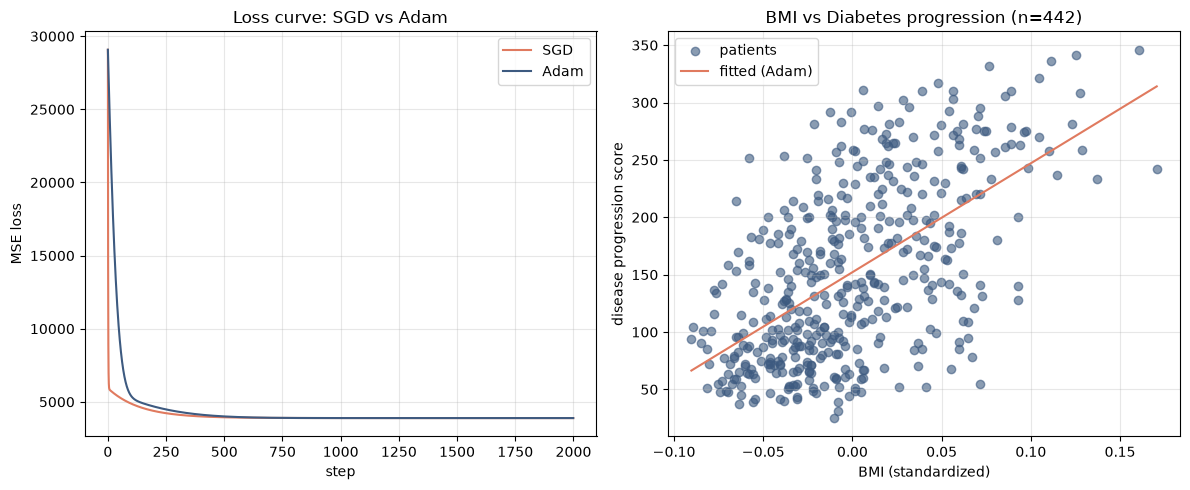

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history_sgd, label="SGD", color="#e07a5f")
axes[0].plot(history_adam, label="Adam", color="#3d5a80")
axes[0].set_title("Loss curve: SGD vs Adam")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(bmi, progression, color="#3d5a80", label="patients", alpha=0.6)
x_line = torch.linspace(bmi.min(), bmi.max(), 100).unsqueeze(1)
axes[1].plot(x_line.numpy(), model_adam(x_line).detach().numpy(), color="#e07a5f", label="fitted (Adam)")
axes[1].set_title("BMI vs Diabetes progression (n=442)")
axes[1].set_xlabel("BMI (standardized)")
axes[1].set_ylabel("disease progression score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/assets/training_result.png", dpi=150)
plt.show()

## 5. 정리

- `loss.backward()`는 순전파에서 만들어진 계산 그래프를 거꾸로 타고 올라가며
  `w`, `b` 각각에 대한 기울기를 누적한다 — `torchviz`로 그 경로를 직접 확인했다.
- 실제 임상 데이터에서도 BMI 하나만으로는 노이즈가 커서 완벽한 직선 피팅이
  되지 않는다는 것을 산점도에서 확인할 수 있었다 (강의의 인위적 예제와의 차이점).
- 같은 문제에서도 옵티마이저 선택에 따라 수렴 속도가 달라진다는 것을
  SGD/Adam 비교 실험으로 확인했다.

### 다음에 이어서 정리할 내용
- 여러 피처(BMI 외 혈압, 혈당 수치 등)를 함께 사용하는 다중 선형회귀
- 신경망(여러 층) 모델로 확장
- 분류(Classification) 문제

---
*이 노트북은 [HongLab AI](https://www.honglab.ai/) 강의를 학습한 뒤, 강의와 무관한
실제 공개 데이터셋(scikit-learn diabetes dataset)으로 직접 재구성한
개인 학습 포트폴리오입니다.*